### Calculation of the ratio S/N

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#In[2]:
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprosess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster()

In [3]:
# print(client)

### Input both the forced and ICV_std trend data 

In [4]:
dir_forced= '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/trend_forced_HadCRUT5_annual/'
variable_name = np.arange(2013,1949,-1).astype(str)
segment_lengths = np.arange(10, 74, 1).astype(str)

# input into the dataset
file = dir_forced + 'forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc'
HadCRUT5_forced_ds = xr.open_mfdataset(file).trend
print(HadCRUT5_forced_ds)

<xarray.DataArray 'trend' (period: 64, lat: 90, lon: 180)>
dask.array<open_dataset-3fd51ec051921d1dd60184dee3245d92trend, shape=(64, 90, 180), dtype=float64, chunksize=(64, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'


In [5]:
HadCRUT5_forced_ds.sel(period='1950-2022')

<xarray.DataArray 'trend' (lat: 90, lon: 180)>
dask.array<getitem, shape=(90, 180), dtype=float64, chunksize=(90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
    period   <U9 '1950-2022'

In [6]:
# Input the standard deviation of SAT-OBS residuals
dir_std = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/OBS_ICV_std/concatenate/'

file = dir_std + 'OBS_ICV_MK_trend_STD_1950_2022_sliding.nc'
ds = xr.open_mfdataset(file)

HadCRUT5_ICV_std_ds  = ds['icv_trend_std']
    
print(HadCRUT5_ICV_std_ds)

<xarray.DataArray 'icv_trend_std' (period: 64, trend_length: 64, lat: 90,
                                   lon: 180)>
dask.array<open_dataset-020710578a1f1e51be676bb2aba32b40icv_trend_std, shape=(64, 64, 90, 180), dtype=float64, chunksize=(64, 64, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * trend_length  (trend_length) int64 10 11 12 13 14 15 ... 68 69 70 71 72 73
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * period        (period) object '2013-2022' '2012-2022' ... '1950-2022'


In [7]:
HadCRUT5_ICV_std_ds

<xarray.DataArray 'icv_trend_std' (period: 64, trend_length: 64, lat: 90,
                                   lon: 180)>
dask.array<open_dataset-020710578a1f1e51be676bb2aba32b40icv_trend_std, shape=(64, 64, 90, 180), dtype=float64, chunksize=(64, 64, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * trend_length  (trend_length) int64 10 11 12 13 14 15 ... 68 69 70 71 72 73
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * period        (period) object '2013-2022' '2012-2022' ... '1950-2022'

In [8]:
# define function to calculate the ratio of the trend pattern of each segment to the standard deviation of the trend pattern of each interval of segments
def SNR_trend_pattern(data, std_trend_pattern):
    """
    data: 2D array with dimensions [lat, lon]
    std_trend_pattern: 2D array with dimensions [lat, lon]
    """
    return data/std_trend_pattern

In [9]:
len_segments = np.arange(10, 74, 1)
import os
start_year = 1950
end_year   = 2022
min_length = 10
period_starts = list(range(end_year - min_length + 1, start_year - 1, -1))  # 2013..1950
period_labels = [f"{by}-{end_year}" for by in period_starts]

In [10]:
# Calculate the trend pattern of each segment
#       and calculate the ensemble standard deviation of the trend pattern of each interval of segments
SNR_trend_pattern_ds = xr.Dataset()
for L, period_label in zip(len_segments, period_labels):
    print(f'Calculating SNR for trend length: {L}, period: {period_label}')
    variable_name = f'SNR_{L}_trend'
    SNR_trend_pattern_ds[variable_name] = SNR_trend_pattern(HadCRUT5_forced_ds.sel(period=period_label), HadCRUT5_ICV_std_ds.sel(period=period_label, trend_length=L))

print(SNR_trend_pattern_ds[variable_name])

Calculating SNR for trend length: 10, period: 2013-2022
Calculating SNR for trend length: 11, period: 2012-2022
Calculating SNR for trend length: 12, period: 2011-2022
Calculating SNR for trend length: 13, period: 2010-2022
Calculating SNR for trend length: 14, period: 2009-2022
Calculating SNR for trend length: 15, period: 2008-2022
Calculating SNR for trend length: 16, period: 2007-2022
Calculating SNR for trend length: 17, period: 2006-2022
Calculating SNR for trend length: 18, period: 2005-2022
Calculating SNR for trend length: 19, period: 2004-2022
Calculating SNR for trend length: 20, period: 2003-2022
Calculating SNR for trend length: 21, period: 2002-2022
Calculating SNR for trend length: 22, period: 2001-2022
Calculating SNR for trend length: 23, period: 2000-2022
Calculating SNR for trend length: 24, period: 1999-2022
Calculating SNR for trend length: 25, period: 1998-2022
Calculating SNR for trend length: 26, period: 1997-2022
Calculating SNR for trend length: 27, period: 19

In [11]:
SNR_trend_pattern_ds.values

<bound method Mapping.values of <xarray.Dataset>
Dimensions:       (lat: 90, lon: 180)
Coordinates:
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    period        <U9 '2013-2022'
    trend_length  int64 10
Data variables: (12/64)
    SNR_10_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_11_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_12_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_13_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_14_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_15_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    ...            ...
    SNR_68_trend  (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>
    SNR_69_trend  (lat, lon) f

In [12]:
# check the result max and min
for var in SNR_trend_pattern_ds.data_vars:
    print(var)
    print(SNR_trend_pattern_ds[var].max().values)
    print(SNR_trend_pattern_ds[var].min().values)

SNR_10_trend
1.2394496815136762
-0.23335653193841707
SNR_11_trend
1.426562623490233
-0.2550136055720129
SNR_12_trend
1.6128437745038176
-0.27852932999484625
SNR_13_trend
1.784299079823449
-0.30325182487992697
SNR_14_trend
1.8863167119585145
-0.32635660412577117
SNR_15_trend
2.117589115023637
-0.3450660346233303
SNR_16_trend
2.4083030639572196
-0.38041831753109306
SNR_17_trend
2.6086176196915436
-0.40646424951867605
SNR_18_trend
2.806617114913126
-0.42170204700309355
SNR_19_trend
3.172803475534871
-0.440157420244642
SNR_20_trend
3.347626241080492
-0.45796915088561985
SNR_21_trend
3.571443488119505
-0.4736684382158325
SNR_22_trend
3.783326694566403
-0.4822384109472143
SNR_23_trend
4.10790375980137
-0.5024814398127994
SNR_24_trend
4.200483512688344
-0.5226163178250212
SNR_25_trend
4.435018099735838
-0.5447172955301154
SNR_26_trend
4.645711191509755
-0.5711628545854643
SNR_27_trend
4.909111736719974
-0.6013000511515227
SNR_28_trend
5.483043411826498
-0.6292574313144145
SNR_29_trend
5.87638

In [13]:
# save the output 
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG4/'

for segment_length in segment_lengths:
    file_out = dir_out + 'SNR_trend_pattern_HadCRUT5_'+segment_length+'yr_segments_ends_2022.nc'
    SNR_trend_pattern_ds[f'SNR_{segment_length}_trend'].to_netcdf(file_out)

### Plot the SNR ratio according to the trend length

In [14]:
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.transparent'] = True
plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['legend.frameon']      = False
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap

In [15]:
# # define an asymmetric colormap
# from matplotlib.colors import LinearSegmentedColormap, Normalize
# from matplotlib.colors import BoundaryNorm
# # define the color bar with [-1.0, 1.0] in grey and the rest in blue and red-0.75, -0.5, -0.25, 0.25, 0.5, 0.75,

# intervals = [-10.0,-9.0,-8.0,-7.0,-6.0,-5.0,-4.0,-3.0, -1.0, -1.0,-0.75,-0.5, -0.25, 
#             0.25, 0.5, 0.75, 1.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# colors = [
#     [0,19,97],
#     [3,39,110],
#     [3,60,124],
#     [5,81,137],
#     [23,104,153],
#     [57,130,171],
#     [100,159,190],
#     [140,186,208],
#     [182,211,224],
#     [224,230,233], # blue
#     [77,77,77],# grey
#     [135,135,135],
#     [186,186,186],
#     [224,224,224],
#     [186,186,186],
#     [135,135,135],
#     [77,77,77],# grey
#     [238,221,211],# red
#     [229,192,173],
#     [219,168,139],
#     [208,144,107],
#     [198,119,73],
#     [187,96,45],
#     [165,63,15],
#     [137,38,7],
#     [111,18,8],
#     [89,0,9],
#     [255,255,255]
#     ]

# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
# define the color bar with [-1.0, 1.0] in grey and the rest in blue and red
# -10.0,-9.0,-8.0,-7.0,-6.0,-5.0,-4.0,-3.0, -1.0, -0.75, -0.5, -0.25, 0.25, 0.5, 0.75,

intervals = [-1.0, 1.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
# intervals = np.arange(-1.0, 11.0, 1.0)
# colors = [
#     [186,186,186],
#     # [224,224,224],
#     # [186,186,186],
#     # [135,135,135],
#     # [77,77,77],# grey
#     [235,221,219],# red
#     [223,189,178],
#     [214,159,141],
#     [204,129,104],
#     [208,144,107],
#     [194,96,66],
#     [182,64,41],
#     [161,30,37],
#     [131,14,41],
#     [94,14,33],
#     [60,9,18]
#     ]
# Reds
colors = [
    [186,186,186],
    # [224,224,224],
    # [186,186,186],
    # [135,135,135],
    # [77,77,77],# grey
    [255,245,240],# red
    [254,224,210],
    [252,187,161],
    [252,146,114],
    [251,106,74],
    [239,59,44],
    [203,24,29],
    [165,15,21],
    [103,0,13]
    ]
# colors = [
#     [186,186,186],
#     # [224,224,224],
#     # [186,186,186],
#     # [135,135,135],
#     # [77,77,77],# grey
#     [250,230,197],# red
#     [245,185,152],
#     [237,138,129],
#     [230,113,117],
#     [199,88,108],
#     [156,63,93],
#     [112,40,74]
#     ]

In [16]:
# colors_normalized = np.array(colors) / 255.0
# cmap =  LinearSegmentedColormap.from_list("custom_colormap", colors_normalized, N=len(colors))

# # Create a BoundaryNorm for mapping colors to the intervals
# norm = BoundaryNorm(intervals, ncolors=cmap.N, clip=True)

In [17]:
# lat = SNR_trend_pattern_ds.lat.values
# lon = SNR_trend_pattern_ds.lon.values

# titles = ["10-year(2013-2022)", "30-year(1993-2022)", "60-year(1963-2022)"]
# titles_left = ["a", "b", "c"]

# import cartopy.util as cutil

# # Create figure with constrained_layout
# fig = plt.figure(figsize=(15, 10), constrained_layout=True)
# gs = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1])
# levels = intervals
# extend = 'max'

# # 10-year plot (top-left)
# ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.Robinson(180))

# Ratio_data = SNR_trend_pattern_ds['SNR_10_trend'].values
# Ratio_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(Ratio_data, coord=lon)
# contour_obj = plot_trend(Ratio_with_cyclic, lat, lon_with_cyclic,levels=levels,extend=extend,
#                     cmap=cmap,
#                     norm=norm,
#                     title=titles[0], ax=ax1, show_xticks = False, show_yticks = True)
# ax1.text(-0.015, 1.08, titles_left[0], fontsize=22, weight='bold', ha='center', va='center',
#             rotation='horizontal', transform=ax1.transAxes)

# # 30-year plot (top-right)
# ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.Robinson(180))

# Ratio_data1 = SNR_trend_pattern_ds['SNR_30_trend'].values
# Ratio_with_cyclic1, lon_with_cyclic = cutil.add_cyclic_point(Ratio_data1, coord=lon)
# contour_obj1 = plot_trend(Ratio_with_cyclic1, lat, lon_with_cyclic,levels=levels,extend=extend,
#                     cmap=cmap,
#                     norm=norm,
#                     title=titles[1], ax=ax2, show_xticks = False, show_yticks = True)
# ax2.text(-0.015, 1.08, titles_left[1], fontsize=22, weight='bold', ha='center', va='center',
#             rotation='horizontal', transform=ax2.transAxes)
# # 60-year plot (bottom-center)
# # fig = plt.figure(figsize=(20, 10))

# ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.Robinson(180))
# # define the figure size and projection
# Ratio_data2 = SNR_trend_pattern_ds['SNR_60_trend'].values
# Ratio_with_cyclic2, lon_with_cyclic = cutil.add_cyclic_point(Ratio_data2, coord=lon)

# contour_obj2 = plot_trend(Ratio_with_cyclic2, lat, lon_with_cyclic,levels=levels,extend=extend,
#                     cmap=cmap,
#                     norm=norm,
#                     title=titles[2], ax=ax3, show_xticks = True, show_yticks = True)
# ax3.text(-0.015, 1.08, titles_left[2], fontsize=22, weight='bold', ha='center', va='center',
#             rotation='horizontal', transform=ax3.transAxes)

# cbar_ax = fig.add_axes([0.34, -0.02, 0.32, 0.02])
# cbar = plt.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal',ticks=[-1.0, 1.0, 1.0, 3.0, 4.0,5.0,
#             6.0, 7.0, 8.0, 9.0, 10.0], extend='max')
# cbar.ax.tick_params(labelsize=14)
# cbar.set_label('Signal/Noise ratio', fontsize=16)

# fig.savefig('SNR_Check.png', dpi=300, bbox_inches='tight')

# plt.show()

### Steps:
1. Stack the SNR values for each trend length: This will give each grid point a series of SNR values corresponding to different trend lengths.
2. Find the first trend length where SNR >= 1.0: For each grid point, check the SNR values across all trend lengths and identify the first trend length where SNR exceeds or equals 1.0.
3. Store the corresponding trend length: Create a 2D array (lat × lon) where each grid point holds the first trend length that meets the SNR condition.
4. Plot the results: Use contour shading to visualize the trend length where SNR first exceeds 1.0.

In [18]:
# Define the range of trend lengths you're analyzing
trend_lengths = np.arange(10, 74)

# Stack the data into a new dimension for trend lengths
stacked_snr = xr.concat([SNR_trend_pattern_ds[f'SNR_{t}_trend'] for t in trend_lengths], dim='trend_length')
stacked_snr = stacked_snr.assign_coords(trend_length=trend_lengths)

In [19]:
type(stacked_snr.trend_length)

xarray.core.dataarray.DataArray

In [20]:
# # Define a function to find the first occurrence of SNR >= 1.0
# def first_valid_trend_length(snr_data):
#     # Use np.argmax to find the first index where SNR >= 1.0
#     condition = snr_data >= 1.0
#     first_valid_idx = np.argmax(condition, axis=0)
    
#     # If no valid index is found, set to NaN (ignore if all are less than 1.0)
#     no_valid = np.all(~condition, axis=0)
#     first_valid_idx[no_valid] = np.nan
    
#     return first_valid_idx

In [21]:
# def first_valid_trend_length(snr_values):
#     """
#     Find the first trend length where SNR >= 1.0.
    
#     Args:
#     - snr_values (np.ndarray): Array of SNR values for a specific grid point across all trend lengths.
    
#     Returns:
#     - first_valid_idx (np.ndarray or float): The index of the first trend length where SNR >= 1.0, 
#                                              or NaN if no such trend length is found.
#     """
#     # Mask negative SNR values by treating them as NaN
#     # snr_values = np.where(snr_values < 0, np.nan, snr_values)

#     # Check where SNR is >= 1.0
#     condition = abs(snr_values) > 1.0
    
#     # Get the index of the first valid trend length where SNR >= 1.0
#     if np.any(condition):
#         first_valid_idx = np.argmax(condition, axis=0)
#     else:
#         first_valid_idx = np.nan  # Return NaN if no trend length satisfies the condition
    
#     return first_valid_idx

In [22]:
def first_valid_trend_length(snr_values):
    """
    Find the first trend length where SNR > 1.0 and all subsequent SNR values are persistently > 1.0.
    
    Args:
    - snr_values (np.ndarray): Array of SNR values for a specific grid point across all trend lengths.
    
    Returns:
    - first_valid_idx (int or float): The index of the first trend length where SNR > 1.0 persistently,
                                      or NaN if no such trend length is found.
    """
    # Check where SNR > 1.0
    condition = snr_values > 1.0

    # Find the index of the first occurrence of SNR > 1.0
    for idx in range(len(condition)):
        # Check if SNR > 1.0 from this index onward is all True
        if condition[idx] and np.all(condition[idx:]):
            return idx  # Return the first valid index
    
    # If no valid index is found, return NaN
    return np.nan

In [23]:
snr_values = np.array([0.5, 0.8, 1.2, 1.5, 1.6])  # Example data
result = first_valid_trend_length(snr_values)
print("First valid trend length index:", result)

First valid trend length index: 2


In [24]:
trend_lengths

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73])

In [25]:
# Apply the function to find the first trend length where SNR >= 1.0
first_trend_idx = xr.apply_ufunc(
    first_valid_trend_length, 
    stacked_snr.chunk(dict(trend_length=-1)),  # Ensure the data is chunked along the trend_length dimension
    input_core_dims=[['trend_length']],  # Apply function along each grid point
    vectorize=True,                      # Apply in a vectorized way
    dask='parallelized',                 # Enable parallel computation with Dask
    output_dtypes=[float],               # Output will be float (since it may contain NaN)
)

In [26]:
# Step 1: Convert first_trend_idx to integers, but keep NaNs intact
first_trend_idx_int = first_trend_idx.fillna(-1).astype(int)  # Replace NaNs with -1 temporarily

# Step 2: Map indices to actual trend lengths
first_trend_length_array = xr.DataArray(
    np.where(first_trend_idx_int >= 0, trend_lengths[first_trend_idx_int], np.nan),  # Use trend lengths for valid indices, NaN for invalid
    dims=['lat', 'lon'],  # Keep lat/lon dimensions
    coords={'lat': first_trend_idx.lat, 'lon': first_trend_idx.lon}
)

In [27]:
print(np.unique(first_trend_length_array.values))

[10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27.
 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.
 46. 47. 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63.
 64. 65. 66. 67. 68. 69. 71. 72. 73. nan]


In [28]:
type(first_trend_length_array)

xarray.core.dataarray.DataArray

In [29]:
first_trend_length_array

<xarray.DataArray (lat: 90, lon: 180)>
array([[28., 28., 28., ..., 28., 28., 28.],
       [29., 29., 29., ..., 29., 29., 29.],
       [31., 31., 31., ..., 31., 31., 31.],
       ...,
       [11., 11., 12., ..., 11., 11., 11.],
       [11., 11., 11., ..., 11., 11., 11.],
       [11., 11., 11., ..., 11., 11., 11.]])
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [30]:
print(first_trend_length_array.shape)

(90, 180)


In [31]:
# Apply the function to each grid point across all trend lengths
def is_monotonic_after_first(snr_values):
    """
    Check if |S/N| values exceed 1.0 at some point and stay above 1.0 for all subsequent trend lengths.

    Args:
        snr_values (np.ndarray): Array of S/N values across trend lengths.

    Returns:
        bool: True if from the first instance of |S/N| > 1.0 onwards, all values remain > 1.0.
    """
    # Find the first index where |S/N| > 1.0
    condition = np.abs(snr_values) > 1.0
    first_valid_idx = np.argmax(condition) if np.any(condition) else None

    if first_valid_idx is None:
        # No S/N > 1.0, return False
        return False

    # Check if all subsequent values are also > 1.0
    return np.all(np.abs(snr_values[first_valid_idx:]) > 1.0)

In [32]:
monotonic_map = xr.apply_ufunc(
    is_monotonic_after_first,
    stacked_snr.chunk(dict(trend_length=-1)),  # Ensure the data is chunked along the trend_length dimension
    input_core_dims=[['trend_length']],  # Apply function along each grid point
    vectorize=True,                      # Apply in a vectorized way
    dask='parallelized',                 # Enable parallel computation with Dask
    output_dtypes=[bool]  # Output is boolean (True/False)
)

In [33]:
monotonic_map

<xarray.DataArray 'SNR_10_trend' (lat: 90, lon: 180)>
dask.array<transpose, shape=(90, 180), dtype=bool, chunksize=(90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
    period   <U9 '2013-2022'

In [34]:
dir_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG4/median_SNgt1/'

In [35]:
def plot_trend(lons, lats, data, levels=None, extend=None, cmap=None, norm=None,
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
# Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 15), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
        
    # contour_obj = ax.contourf(lons, lats, data, levels=levels, extend=extend, 
    #                         cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
    # Assuming lons, lats, data, levels, cmap, norm, and extend are already defined
    pcolormesh_obj = ax.pcolormesh(lons, lats, data, norm=norm, cmap=cmap, shading='auto',
                                   transform=ccrs.PlateCarree())
    # pcolormesh_obj = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, 
    # add_colorbar=False)

    # Plot significance masks with different hatches
    # ax.contourf(lons, lats, significance_mask, levels=[0.05, 1.0],hatches=['///'], colors='none', transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linewidth=1, linestyle='--',
                      color='gray', alpha=0.35)

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontsize=24, pad=5.0)

    return pcolormesh_obj

In [36]:
# Check for NaN values
nan_indices = np.isnan(first_trend_length_array)

# Now you can print or analyze these points
print("NaN indices:", np.where(nan_indices))


NaN indices: (array([10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
       15, 

In [37]:
# check the boolean value True or False
print("Monotonic map shape:", monotonic_map.shape)
# Check for True or False values
true_indices = np.where(monotonic_map.values == True)
# Now you can print or analyze these points
print("True indices:", true_indices)

Monotonic map shape: (90, 180)
True indices: (array([ 0,  0,  0, ..., 89, 89, 89]), array([  0,   1,   2, ..., 177, 178, 179]))


In [38]:
# # WH box (lat 42 to 60, lon 310 to 350)
# wh_box = first_trend_length_array.sel(lat=slice(42, 60), lon=slice(310, 350))
# print("WH Box First Trend Length Values:\n", wh_box.values)

In [39]:
# so_box = first_trend_length_array.sel(lat=slice(-90, -42), lon=slice(180, 200))
# print("SO Box First Trend Length Values:\n", so_box.values)

In [40]:
import copy
import matplotlib as mpl
import matplotlib.colors as mcolors
import palettable
import cartopy.util as cutil
import numpy.ma as ma

# cmdict = cmocean.cm.matter
# norm = mcolors.Normalize(vmin=10, vmax=74)

In [41]:
print(trend_lengths)

[10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57
 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73]


Shape of Ratio_with_cyclic: (90, 181)
Shape of lon_with_cyclic: (181,)
Shape of SNR_trend_pattern_ds.lat: (90,)


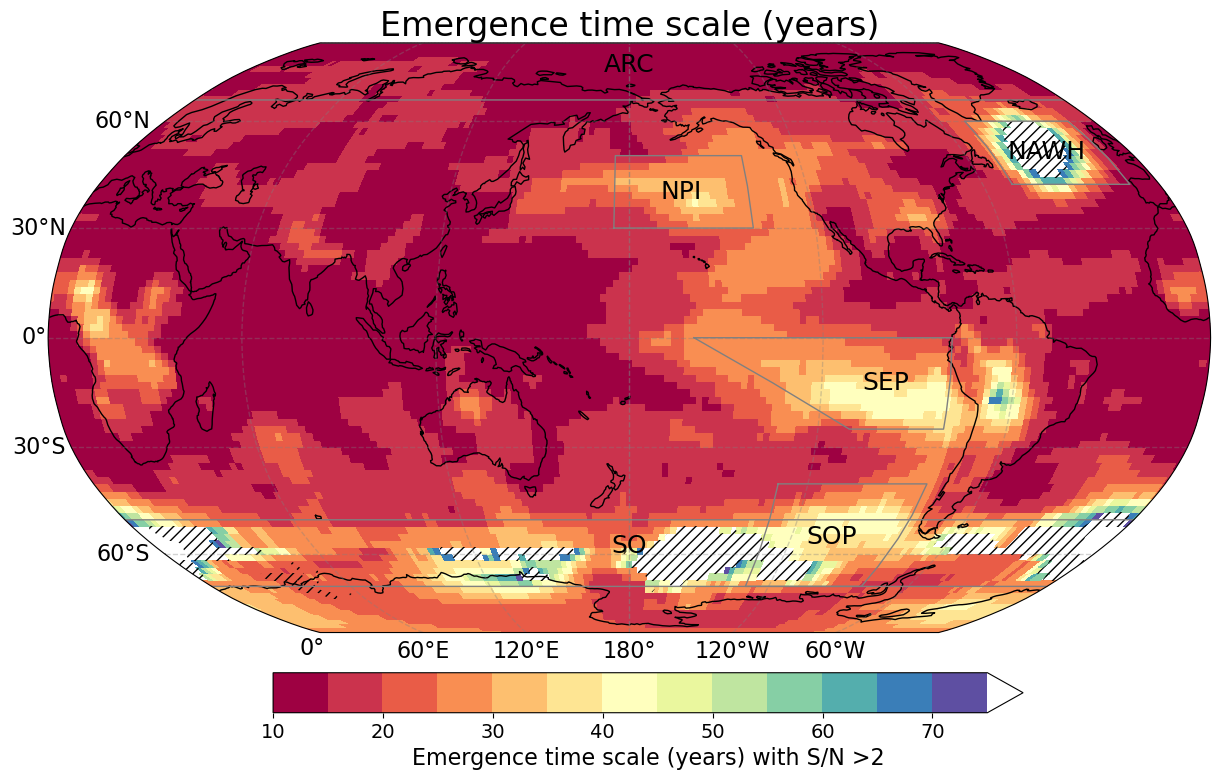

In [42]:
# Plot the first trend length where SNR >= 1.0
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.Robinson(180)})
trend_lengths = np.append(np.arange(10, 75, 5), 75)  # [10, 15, ..., 75, 80]
# cmap_base = plt.get_cmap('OrRd_r')
cmap_base = plt.get_cmap('Spectral')

colors = cmap_base(np.linspace(0, 1, len(trend_lengths) - 1))  # One less than number of edges
colors = np.vstack([colors, [1, 1, 1, 1]])  # Add white at the end for >75 years
custom_cmap = ListedColormap(colors)
norm = BoundaryNorm(trend_lengths, ncolors=len(trend_lengths) - 1)

# trend_lengths = np.arange(10, 80, 5)  # Define the range of trend lengths
# # Make a copy of the colormap before modifying it
# cmap = copy.copy(plt.get_cmap('OrRd_r'))  # Use 'OrRd_r' reversed colormap

# # Define BoundaryNorm for discrete colormap intervals
# norm = BoundaryNorm(trend_lengths, cmap.N)  # cmap.N defines the number of colors in the colormap

# extend = 'neither'  # No extension beyond the colormap range
# cmdict_r = cmdict.reversed()

# Mask invalid data (NaN or Inf values)
masked_array = ma.masked_invalid(first_trend_length_array)

# Add cyclic point to data and longitude
Ratio_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(masked_array, coord=first_trend_length_array.lon)

# Check the shapes to ensure consistency
print("Shape of Ratio_with_cyclic:", Ratio_with_cyclic.shape)
print("Shape of lon_with_cyclic:", lon_with_cyclic.shape)
print("Shape of SNR_trend_pattern_ds.lat:", SNR_trend_pattern_ds.lat.shape)

# Plot the data (ensure 'contour' is the correct mappable object)
pcolormesh_plot = plot_trend(lon_with_cyclic, SNR_trend_pattern_ds.lat, Ratio_with_cyclic,
                                    levels=trend_lengths, extend='max', cmap=custom_cmap, norm=norm,
                                        title='Emergence time scale (years)', ax=ax, show_xticks=True, show_yticks=True)
# Assume monotonic_map is a boolean DataArray (True = monotonic, False = not monotonic)
# and first_trend_length_array is your main data

# Add cyclic point to monotonic_map for plotting
monotonic_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(monotonic_map.values, coord=monotonic_map.lon)

# Overlay the monotonicity mask as hatching (False = not monotonic)
ax.contourf(
    lon_with_cyclic, SNR_trend_pattern_ds.lat, ~monotonic_with_cyclic,
    levels=[0.5, 1.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree(), alpha=0
)

# Add the regional outlines and calculate midpoints for labels:
# Arctic box
arctic_lon_mid = (0 + 360) / 2
arctic_lat_mid = (66.5 + 90) / 2
ax.plot([0, 360, 360, 0, 0], [66.5, 66.5, 90, 90, 66.5],
        color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(arctic_lon_mid, arctic_lat_mid, 'ARC', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for Arctic
"""
tEst boxes:
- SO box: lon 0 to 360, lat -70 to -50
- North Pacific box: lon 210 to 270, lat 30 to 50
"""
# SO box 
so_lon_mid = (0 + 360) / 2
so_lat_mid = (-65 + -50) / 2
ax.plot([0, 360, 360, 0, 0], [-70, -70, -50, -50, -70],
        color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(so_lon_mid, so_lat_mid, 'SO', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for SO
# Extratropical South Pacific box
sop_lon_mid = (230 + 280) / 2
sop_lat_mid = (-40 + -70) / 2
ax.plot([230%360, 280%360, 280%360, 230%360, 230%360], [-40, -40, -70, -70, -40],
        color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(sop_lon_mid, sop_lat_mid, 'SOP', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for SOP

# North Pacific box
npac_lon_mid = (175 + 220) / 2
npac_lat_mid = (30 + 50) / 2
ax.plot([175%360, 220%360, 220%360, 175%360, 175%360], [30, 30, 50, 50, 30],
        color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(npac_lon_mid, npac_lat_mid, 'NPI', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for NPI     
# WH box
wh_lon_mid = (310 + 350) / 2
wh_lat_mid = (42 + 60) / 2
box_lons = np.array([310, 350, 350, 310, 310])
box_lats = np.array([42, 42, 60, 60, 42])
ax.plot(box_lons, box_lats, color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(wh_lon_mid, wh_lat_mid, 'NAWH', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for WH

# Southeast Pacific box
sep_lon_mid = (200 + 320) / 2
sep_lat_mid = (0 + -25) / 2
ax.plot([200%360, 280%360, 280%360, 250%360, 200%360], [0, 0, -25, -25, 0],
        color='grey', linewidth=1.0, transform=ccrs.PlateCarree())
ax.text(sep_lon_mid, sep_lat_mid, 'SEP', color='black', fontsize=18, transform=ccrs.PlateCarree(),
        ha='center', va='center')  # Label for SEP

# Add colorbar for the plot

cbar_ax = fig.add_axes([0.275, 0.12, 0.5, 0.04])
cbar = plt.colorbar(pcolormesh_plot, cax=cbar_ax, orientation='horizontal', extend='max')
# # Customize the colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Emergence time scale (years) with S/N >2', fontsize=16)
FIG_OUT= "/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG4_intermediate_figs/"
fig.savefig(f'{FIG_OUT}OBS_Emergence_Trend_Length_update_CESM2_100_SNgt1.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{FIG_OUT}OBS_Emergence_Trend_Length_update_CESM2_100_SNgt1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
first_trend_length_array.to_dataset(name='emergence_timescale').to_netcdf(dir_output + "OBS_Emergence_time_scale.nc")

In [ ]:
# client.close()
# scluster.close()

### 